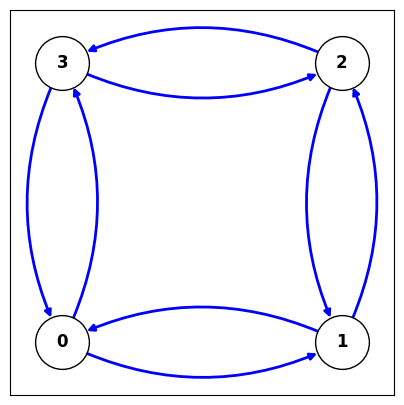

In [1]:
import sys; sys.path.append('../..')
import numpy as np
from src.plot_helpers import plot_topology
import matplotlib.pyplot as plt

topology = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])

ax = plot_topology(topology)

In [2]:
from src.VQE_functions import MFIM_Hamiltonian, build_hva_layers

hx = 2
hz = 2
J = 1

Hamiltonian = MFIM_Hamiltonian(J=J, hx=hx, hz=hz, topology = topology)

hva_layers, params = build_hva_layers(topology=topology, num_layers=1)

values = {p: v for p, v in zip(params, [0.1, 0.2, 0.3])}
qc_bound = hva_layers.assign_parameters(values)

qc_bound.draw(fold=-1)

┌───┐┌─────────┐┌─────────┐                                                          
q_0: ┤ H ├┤ Rz(0.2) ├┤ Rx(0.3) ├──■───────────────■────■──────────────────────────■───────
     ├───┤├─────────┤├─────────┤┌─┴─┐┌─────────┐┌─┴─┐  │                          │       
q_1: ┤ H ├┤ Rz(0.2) ├┤ Rx(0.3) ├┤ X ├┤ Rz(0.1) ├┤ X ├──┼───────■──────────────────┼────■──
     ├───┤├─────────┤├─────────┤└───┘└─────────┘└───┘  │     ┌─┴─┐   ┌─────────┐  │  ┌─┴─┐
q_2: ┤ H ├┤ Rz(0.2) ├┤ Rx(0.3) ├──■───────────────■────┼─────┤ X ├───┤ Rz(0.1) ├──┼──┤ X ├
     ├───┤├─────────┤├─────────┤┌─┴─┐┌─────────┐┌─┴─┐┌─┴─┐┌──┴───┴──┐└─────────┘┌─┴─┐└───┘
q_3: ┤ H ├┤ Rz(0.2) ├┤ Rx(0.3) ├┤ X ├┤ Rz(0.1) ├┤ X ├┤ X ├┤ Rz(0.1) ├───────────┤ X ├─────
     └───┘└─────────┘└─────────┘└───┘└─────────┘└───┘└───┘└─────────┘           └───┘

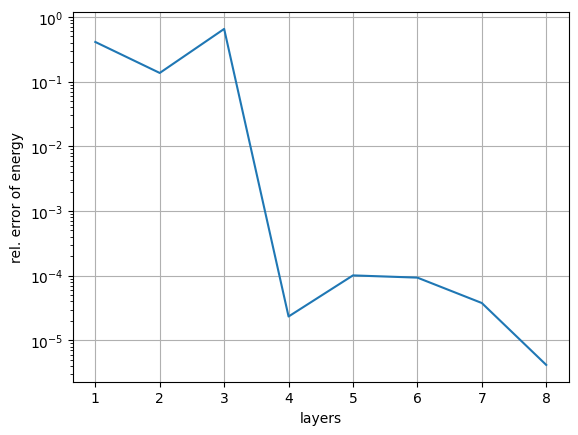

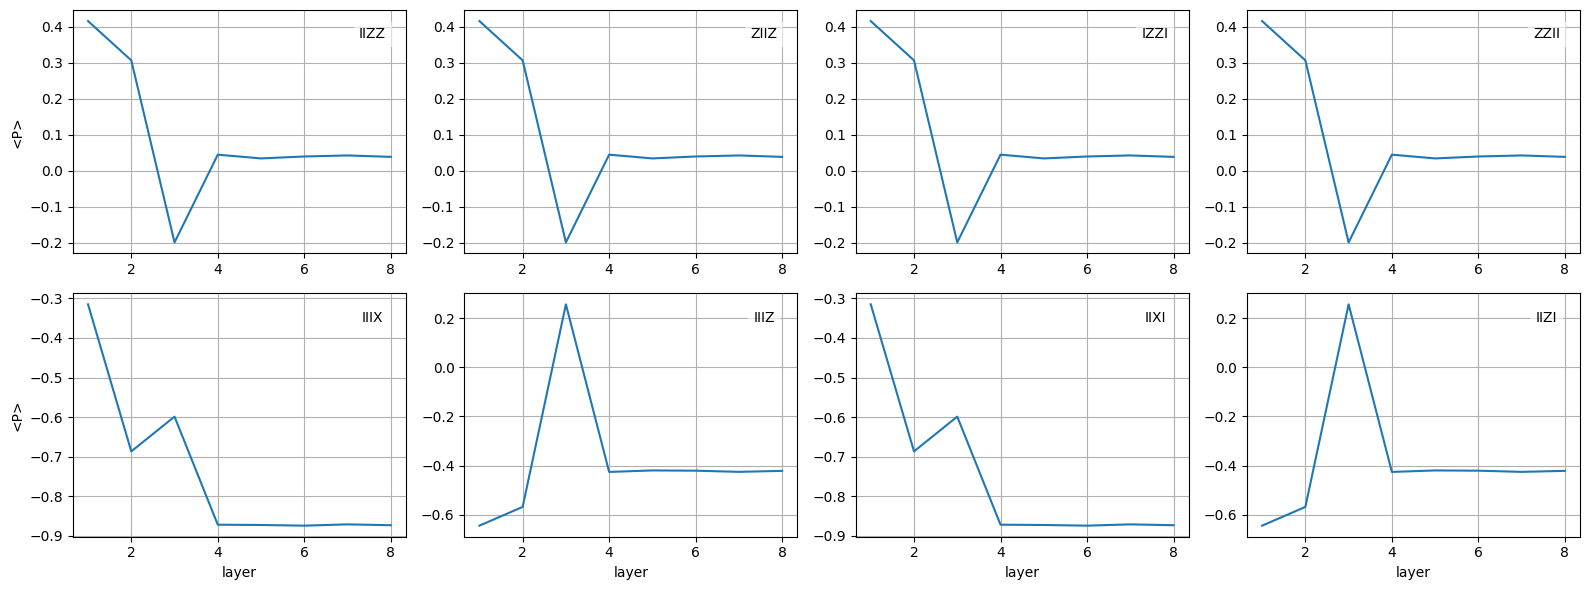

In [3]:
from src.VQE_functions import optimize_energy, init_parameters
from qiskit.transpiler import CouplingMap
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2
from scipy.linalg import eigh
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.quantum_info import Statevector, SparsePauliOp


backend = AerSimulator()

hx = 2
hz = 2
J = 1

Hamiltonian = MFIM_Hamiltonian(J=J, hx=hx, hz=hz, topology = topology)

eigvals = eigh(Hamiltonian.to_matrix(), eigvals_only=True)
exact_energy = np.min(eigvals)

num_layers = 8


pauli_strings = [p.to_label() for p in Hamiltonian.paulis]
pauli_spop = [SparsePauliOp.from_list([(pauli, 1.0)]) for pauli in pauli_strings]
expvals = np.zeros((len(pauli_strings), num_layers))
rel_err = []

for nlayer in range(1, num_layers+1):
    initial_params = np.ones((1,3*nlayer))[0,:]
    bounds = [(-np.pi, np.pi)] * 3* nlayer
    opt_params, energy, HelperInfo = optimize_energy(initial_params= initial_params, Hamiltonian=Hamiltonian, topology=topology, num_layers=nlayer, backend=backend, mode="statevector", method="Powell",bounds = bounds)
    hva_layers, params = build_hva_layers(topology=topology, num_layers=nlayer)
    values = {p: v for p, v in zip(params, opt_params)}
    circuit = hva_layers.assign_parameters(values)
    psi = Statevector.from_instruction(circuit)
    expvals[:,nlayer-1] = [psi.expectation_value(Obs).real for Obs in pauli_spop]
    rel_err.append(np.abs(energy-exact_energy)/np.abs(exact_energy))

plt.plot(np.arange(1,num_layers+1), rel_err)
plt.yscale("log")
plt.xlabel("layers")
plt.ylabel("rel. error of energy")
plt.grid(True)

fig, axes = plt.subplots(2,4, figsize=(16,6))
axes = axes.flatten()
x = np.arange(1,num_layers+1)

for i, ax in enumerate(axes):
    ax.plot(x,expvals[i,:])
    ax.text(0.9,0.9, f"{pauli_strings[i]}", transform= ax.transAxes, ha="center",va= "center", fontsize=10, bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))
    ax.grid(True)
    if i == 0 or i == 4:
        ax.set_ylabel(f"<P>")
    if i > 3:
        ax.set_xlabel("layer")

plt.tight_layout()
plt.show()

In [5]:
import sys; sys.path.append('../..')
import numpy as np
from tqdm.notebook import tqdm
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_aer import AerSimulator
from scipy.linalg import eigh
from src.VQE_functions import MFIM_Hamiltonian, build_hva_layers
from src.VQE_functions import optimize_energy, init_parameters

backend = AerSimulator()

topology = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])
num_layers = 8

hx = 2
hz = 2
J = 1
Hamiltonian = MFIM_Hamiltonian(J=J, hx=hx, hz=hz, topology = topology)


pauli_strings = [p.to_label() for p in Hamiltonian.paulis]
pauli_spop = [SparsePauliOp.from_list([(pauli, 1.0)]) for pauli in pauli_strings]

N = 2
hx_vals = np.linspace(-10, 10, N)
hz_vals = np.linspace(-10, 10, N)

# Speicher-Arrays
rel_err = np.zeros((N, N, num_layers))
energies = np.zeros((N, N, num_layers))
expvals = np.zeros((N, N, num_layers, len(pauli_strings)))

# Gesamtfortschritt (alle Kombinationen von hx,hz,num_layers)
total_steps = N * N * num_layers

with tqdm(total=total_steps, desc="Parameter sweep", leave=True) as pbar:
    for i, hx in enumerate(hx_vals):
        for j, hz in enumerate(hz_vals):
            H = MFIM_Hamiltonian(J=J, hx=hx, hz=hz, topology=topology)
            eigvals = eigh(H.to_matrix(), eigvals_only=True)
            exact_energy = np.min(eigvals)
            for nlayer in range(1, num_layers+1):
                initial_params = np.ones((1, 3*nlayer))[0, :]
                bounds = [(-np.pi, np.pi)] * 3 * nlayer

                opt_params, energy, HelperInfo = optimize_energy(initial_params=initial_params,Hamiltonian=H,topology=topology,num_layers=nlayer,mode="statevector",method="Powell",bounds=bounds)

                hva_layers, params = build_hva_layers(topology=topology, num_layers=nlayer)
                values = {p: v for p, v in zip(params, opt_params)}
                circuit = hva_layers.assign_parameters(values)
                psi = Statevector.from_instruction(circuit)

                # Erwartungswerte speichern
                for k, Obs in enumerate(pauli_spop):
                    expvals[i, j, nlayer-1, k] = psi.expectation_value(Obs).real

                # Energie- und Fehlerwerte speichern
                energies[i, j, nlayer-1] = energy
                rel_err[i, j, nlayer-1] = np.abs(energy - exact_energy) / np.abs(exact_energy)

                pbar.update(1)


"""np.savez(
    "MFIM_sweep_results.npz",
    hx_vals=hx_vals,
    hz_vals=hz_vals,
    energies=energies,
    rel_err=rel_err,
    expvals=expvals,
    pauli_strings=pauli_strings
)"""

Parameter sweep:   0%|          | 0/32 [00:00<?, ?it/s]

'np.savez(\n    "MFIM_sweep_results.npz",\n    hx_vals=hx_vals,\n    hz_vals=hz_vals,\n    energies=energies,\n    rel_err=rel_err,\n    expvals=expvals,\n    pauli_strings=pauli_strings\n)'

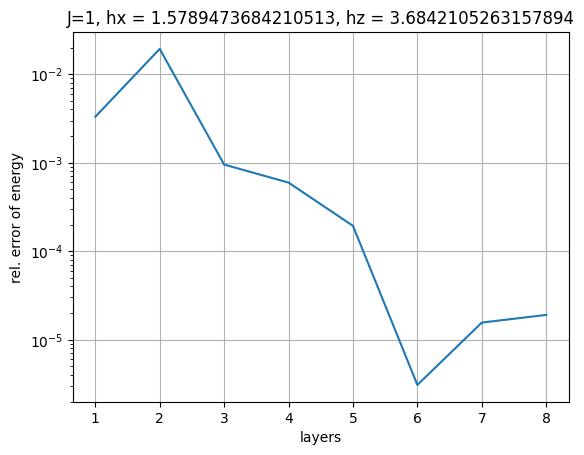

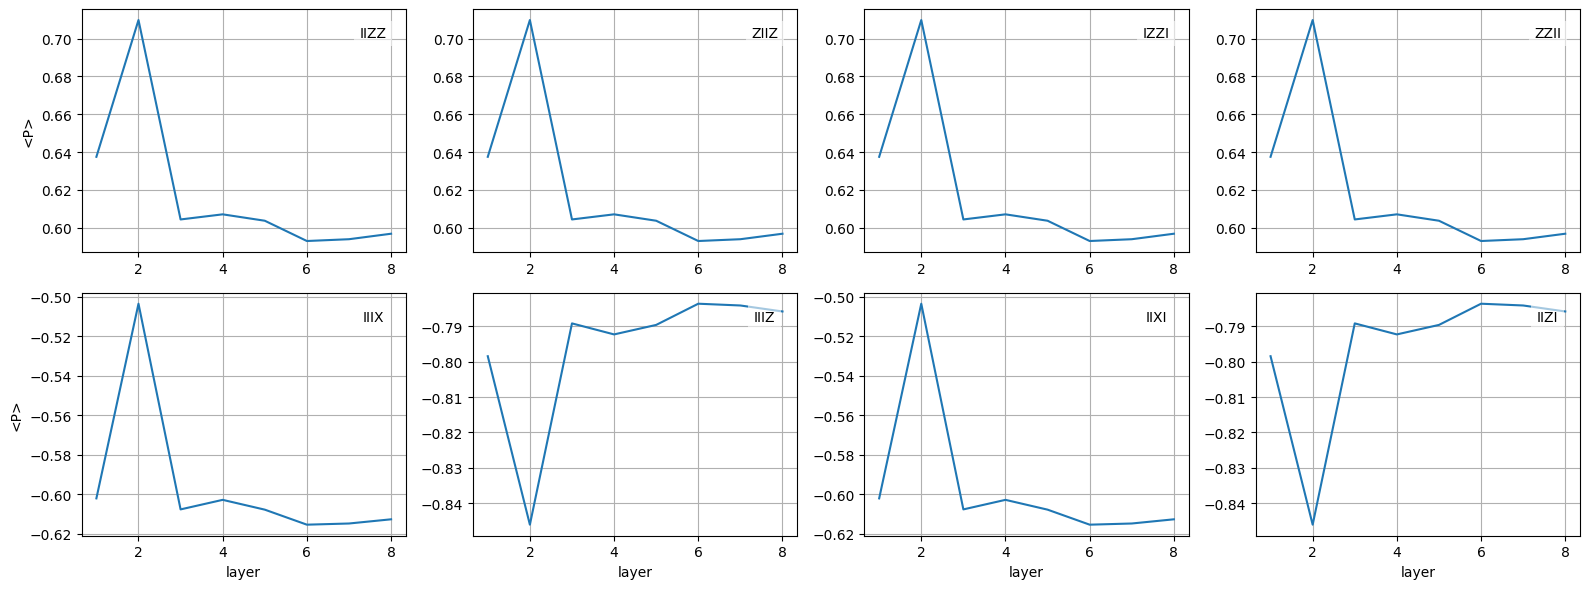

In [ ]:
data = np.load("MFIM_sweep_results.npz", allow_pickle=True)
energies = data["energies"]
rel_err = data["rel_err"]
expvals = data["expvals"]

hx = 2
hz = 4

idx = np.argmin(np.abs(hx_vals-hx))
idz = np.argmin(np.abs(hz_vals-hz))
plt.plot(np.arange(1,num_layers+1), rel_err[idx, idz,:])
plt.title(f"J={J}, hx = {hx_vals[idx]}, hz = {hz_vals[idz]}")
plt.yscale("log")
plt.xlabel("layers")
plt.ylabel("rel. error of energy")
plt.grid(True)

fig, axes = plt.subplots(2,4, figsize=(16,6))
axes = axes.flatten()
x = np.arange(1,num_layers+1)

for i, ax in enumerate(axes):
    ax.plot(x,expvals[idx, idz,:,i])
    ax.text(0.9,0.9, f"{pauli_strings[i]}", transform= ax.transAxes, ha="center",va= "center", fontsize=10, bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))
    ax.grid(True)
    if i == 0 or i == 4:
        ax.set_ylabel(f"<P>")
    if i > 3:
        ax.set_xlabel("layer")

plt.tight_layout()
plt.show()